In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
import matplotlib.patches as patches
from matplotlib import cm

In [2]:
import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

from Neural_Density_Training.Models import (
    Polynomial_net,
    Polynomial_net_bias_zero,
    Numerator_polynomial_net,
    GammaFunctionNet,
)
from Neural_Density_Training.loss import (
    stability_loss,
    invariance_loss,
    safety_loss,
)
from Neural_Density_Training.falsifier import checkSMTconstraints, AddCounterexamples
from Neural_Density_Training.extract_model import SymbolicNN, activSymbolicNN
from Neural_Density_Training.plotter import (
    plot_contour_density,
    plot_contour_mixed_density,
)

## Sample Data 

We will use seed to ensure the reproducibility

In [3]:

torch.cuda.empty_cache()
torch.manual_seed(17)
random.seed()

In [4]:

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Pre-allocate numerical_x
numerical_x = torch.Tensor(500, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


## Define the Dynamics:

We will define the dynamics of the system below. In particular, the dynamics must be described as following:
\begin{align}
    \dot{x}=f(x)+g(x)u(x)
\end{align}

In [5]:

# Physical constants for inverted pendulum
MASS = 0.15
GRAVITY = 9.81
LENGTH = 0.5
FRICTION = 0.1
ML2 = MASS * (LENGTH ** 2)


In [6]:

def f(x):
    """Vectorized inverted pendulum dynamics f(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        x[:, 1],
        (MASS * GRAVITY * LENGTH * torch.sin(x[:, 0]) - FRICTION * x[:, 1]) / ML2
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def g(x):
    """Vectorized g(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        torch.zeros_like(x[:, 0]),
        torch.full_like(x[:, 0], 1.0 / ML2)
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def div_f(x):
    """Vectorized divergence of f - handles batched input"""
    divergence = -FRICTION / ML2
    if x.dim() == 1:
        return torch.tensor(divergence, device=device)
    else:
        return torch.full((x.shape[0],), divergence, device=device)

def div_g(x):
    """Vectorized divergence of g"""
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)

## Describe the constraints

Ideally I would have want this to be automated through utils file as well but sadly dreal doesn't process the functions quite well and hence has to be done manually.

In [7]:

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1],
        (MASS * GRAVITY * LENGTH * sin(vars[0]) - FRICTION * vars[1]) / ML2
    ]
    g_val = [
        0.0 * vars[0],
        1.0 / ML2
    ]
    
    f_div = -FRICTION / ML2
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2
    return a_sym, constraint

## Stable control Training

We implement our control training below.

In [8]:
def train_density(
    x,                          # initial sample tensor  [N, state_dim]
    f,                          # dynamics callable
    g,                          # control matrix callable
    div_f,                      # divergence of f callable
    div_g,                      # divergence of g callable
    device,
    # --- training ---
    epochs          = 2000,
    lr              = 1e-2,
    loss_threshold  = 5e-4,
    # --- SMT verification ---
    ball_lb         = 0.05,
    ball_ub         = 6.0,
    check_interval  = 10,
    n_counterex     = 100,
):
    
    # Instantiate neural networks for a, b, c, gamma
    a_net = Numerator_polynomial_net(layers=2, input_dim=2, hidden_dim=2, output_dim=1).to(device)
    b_net = Polynomial_net_bias_zero(layers=2, input_dim=2, hidden_dim=2, output_dim=1).to(device)
    c_net = Polynomial_net(layers=3, input_dim=2, hidden_dim=12, output_dim=1).to(device)
    gamma_net = GammaFunctionNet(input_dim=2,output_dim=1).to(device)

    
    # Loss and Optimizer
    criterion = stability_loss(f=f,g=g,div_f=div_f,div_g=div_g)

    optimizer = torch.optim.Adam(list(a_net.parameters()) +
                                    list(b_net.parameters()) + 
                                    list(c_net.parameters()) + 
                                    list(gamma_net.parameters()), lr=lr)
    
    # dReal Configuration
    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5   

    # CEGIS Loop
    loss_history = []
    valid = False 
    print("=" * 60)
    print("Training density function with SMT-CEGIS verification")
    print(f"  Initial dataset size: {x.shape[0]}")
    print("=" * 60)    

    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss = criterion(x, a_net, b_net, c_net, gamma_net)         
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

            
            # ---------- early-exit on convergence ----------
            if loss.item() < loss_threshold:
                print(f"  [Epoch {epoch}] Loss {loss.item():.6f} < threshold to checking SMT...")
                valid = True
                break

            # ---------- periodic progress print ------------
            if epoch % 50 == 0:
                print(
                    f"  Epoch {epoch:>5}/{epochs} | "
                    f"Loss: {loss.item():.6f} | "
                    f"Dataset: {x.shape[0]}"
                )            
 
            # ---------- SMT counterexample check -----------
            if epoch % check_interval == 0 and epoch > 0:
                vars_sym = [Variable("x1"), Variable("x2")]
                try:
                    a_sym, div_sym = candidate_constraint_learnt(
                        vars_sym, a_net, b_net, c_net
                    )
                    CE = checkSMTconstraints(
                        vars_sym, a_sym, div_sym, ball_lb, ball_ub, config
                    )
 
                    if CE:
                        before = x.shape[0]
                        x, _ = AddCounterexamples(x, CE, n_counterex, device)
                        after = x.shape[0]
                        print(
                            f"  [Epoch {epoch}] CE found → "
                            f"dataset {before} → {after} (+{after - before})"
                        )
                    else:
                        valid = True
                        print(f"  [Epoch {epoch}] SMT satisfied — no counterexample found ✓")
                        break
 
                except Exception as e:
                    print(f"  [Epoch {epoch}] SMT check failed: {e}")
                    continue
 
    # ------------------------------------------------------------------
    # 5. Final summary
    # ------------------------------------------------------------------
    test_point = torch.zeros(1, 2, dtype=torch.float32, device=device)
    margin     = gamma_net(test_point).item()
 
    print("\n" + "=" * 60)
    print("Training complete")
    print(f"  Final loss     : {loss_history[-1]:.6f}")
    print(f"  Learned margin : {margin:.6f}")
    print(f"  Final dataset  : {x.shape[0]}")
    print("=" * 60)
 
    return loss_history, a_net, b_net, c_net, gamma_net
 

In [9]:
print("=" * 60)
print("INVERTED PENDULUM CONTROL DENSITY LEARNING")
print("=" * 60)

loss_history1, a_net1, b_net1, c_net1, gamma_net1 = train_density(
    x=numerical_x,
    f=f,
    g=g,
    div_f=div_f,
    div_g=div_g,
    device=device,
    epochs=4000,
    lr=1e-3,
    loss_threshold=5e-4,
    ball_lb=0.5,
    ball_ub=6.0,
    check_interval=500,
    n_counterex=100
)

INVERTED PENDULUM CONTROL DENSITY LEARNING
Training density function with SMT-CEGIS verification
  Initial dataset size: 500
  Epoch     0/4000 | Loss: 1.415975 | Dataset: 500
  Epoch    50/4000 | Loss: 0.709822 | Dataset: 500
  Epoch   100/4000 | Loss: 0.421913 | Dataset: 500
  Epoch   150/4000 | Loss: 0.249403 | Dataset: 500
  Epoch   200/4000 | Loss: 0.176111 | Dataset: 500
  Epoch   250/4000 | Loss: 0.133964 | Dataset: 500
  Epoch   300/4000 | Loss: 0.103318 | Dataset: 500
  Epoch   350/4000 | Loss: 0.085705 | Dataset: 500
  Epoch   400/4000 | Loss: 0.071620 | Dataset: 500
  Epoch   450/4000 | Loss: 0.059164 | Dataset: 500
  Epoch   500/4000 | Loss: 0.048382 | Dataset: 500
  [Epoch 500] CE found → dataset 500 → 597 (+97)
  Epoch   550/4000 | Loss: 0.100626 | Dataset: 597
  Epoch   600/4000 | Loss: 0.068774 | Dataset: 597
  Epoch   650/4000 | Loss: 0.057560 | Dataset: 597
  Epoch   700/4000 | Loss: 0.051302 | Dataset: 597
  Epoch   750/4000 | Loss: 0.045096 | Dataset: 597
  Epoch   

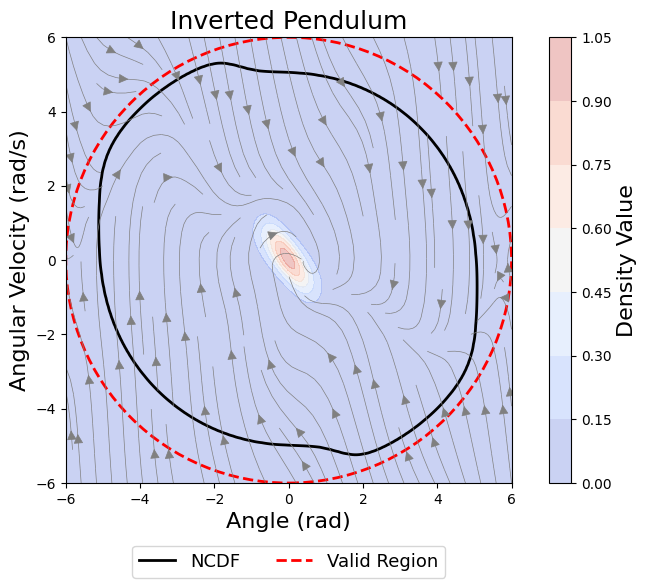

In [10]:
fig,ax = plot_contour_density(
    f=f,
    g=g,
    a=a_net1,
    b=b_net1,
    c=c_net1,
    x_lim = [-6, 6],
    y_lim = [-6, 6],
    density_threshold=1e-14,
    title="Inverted Pendulum",
    x_axis_title="Angle (rad)", y_axis_title="Angular Velocity (rad/s)",
    device=device
)